# Homework 7 - Euler's Method

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Smaller step sizes should stay close to the exact curve, while larger step sizes will drift away and eventually diverge. The local error near x approximately equals 15 should grow as h increases, and the average global error should rise for the same reason.

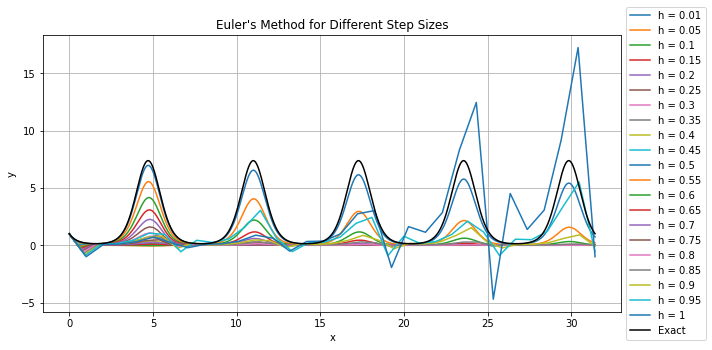

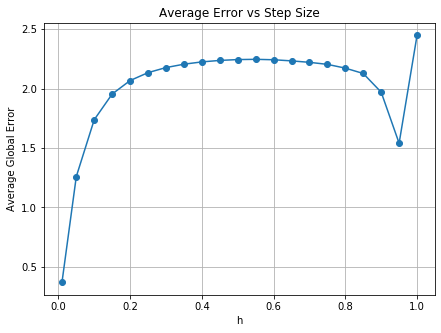

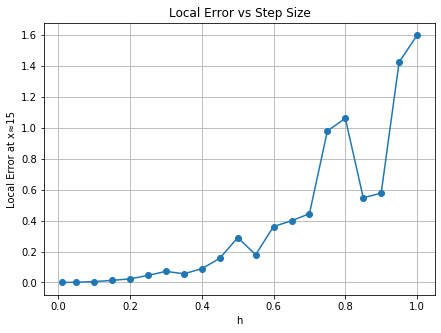

In [2]:
# Define parameters
h_vals = [.01,.05,0.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.95,1]
x_start, x_end = 0, 10 * np.pi

# exact solution for dy/dx = -2y cos(x)
def y_exact(x):
    return np.exp(-2 * np.sin(x))

# store errors for plots
avg_errors = []
local_errors_at_15 = []

plt.figure(figsize=(10, 5))

for h in h_vals:

    # recompute grid for each h
    num_steps = int((x_end - x_start) / h)
    x_values = np.linspace(x_start, x_end, num_steps + 1)
    y_values = np.zeros(num_steps + 1)

    # initial condition
    y_values[0] = 1

    # dy/dx
    def f(x, y):
        return -2 * y * np.cos(x)

    # Euler's method
    for i in range(num_steps):
        y_values[i + 1] = y_values[i] + h * f(x_values[i], y_values[i])

    # global error
    exact_vals = y_exact(x_values)
    global_err = np.abs(y_values - exact_vals)

    # average global error
    avg_errors.append(np.mean(global_err))

    # local error at x ≈ 15
    idx_15 = np.argmin(np.abs(x_values - 15))
    
    if idx_15 < len(x_values) - 1:
        local_err = np.abs(y_exact(x_values[idx_15]) + h * f(x_values[idx_15], y_exact(x_values[idx_15])) -y_exact(x_values[idx_15 + 1]))
        local_errors_at_15.append(local_err)
        
    else:
        local_errors_at_15.append(np.nan) #had to look up how to skip this point
        

    # plot Euler solution
    plt.plot(x_values, y_values, label=f"h = {h}")
    

# exact solution
x_fine = np.linspace(x_start, x_end, 5000)
plt.plot(x_fine, y_exact(x_fine), 'k', label="Exact")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Euler's Method for Different Step Sizes")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True)
plt.tight_layout()
plt.show()

# plot average error vs h
plt.figure(figsize=(7,5))
plt.plot(h_vals, avg_errors, 'o-')
plt.xlabel("h")
plt.ylabel("Average Global Error")
plt.title("Average Error vs Step Size")
plt.grid(True)
plt.show()

# plot local error at x≈15 vs h
plt.figure(figsize=(7,5))
plt.plot(h_vals, local_errors_at_15, 'o-')
plt.xlabel("h")
plt.ylabel("Local Error at x≈15")
plt.title("Local Error vs Step Size")
plt.grid(True)
plt.show()


The exact solution sits above all the Euler curves for small step sizes h because Euler’s method consistently undersetimates the true curve for this differential equation. The slope -2ycos(x) is negative whenever cos(x) is greater than 0, so each Euler step/leap drops too far compared to the true curved solution, and that small downward bias builds up over the given interval. As h increases, the underestimate becomes larger and compounds faster, which is why the Euler curves either sag farther below the exact curve or blow up and the global and local errors grow with increasing step size.

# Addendum

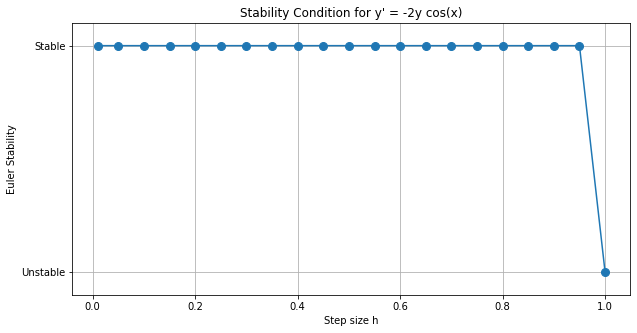

In [3]:
h_vals = [.01,.05,0.1,.15,.2,.25,.3,.35,.4,.45,.5,.55,.6,.65,.7,.75,.8,.85,.9,.95,1]
x = np.linspace(0, 10*np.pi, 5000)

# lambda(x) = -2 cos(x)
lam = -2 * np.cos(x)

# Only check stability where lambda(x) < 0  (i.e., cos(x) > 0)
mask = lam < 0

stability = []

for h in h_vals:
    A = 1 + h * lam[mask]      # amplification factor
    stable = np.all(np.abs(A) < 1)
    stability.append(stable)

# Plot stability results
plt.figure(figsize=(10,5))
plt.plot(h_vals, stability, 'o-', markersize=8)
plt.ylim(-0.1, 1.1)
plt.yticks([0,1], ["Unstable", "Stable"])
plt.xlabel("Step size h")
plt.ylabel("Euler Stability")
plt.title("Stability Condition for y' = -2y cos(x)")
plt.grid(True)
plt.show()


We apply the same idea as in the f(x,y)=-2ycosx case by rewriting the equation in the form y'=lambda(x)*y, where the x-dependence makes lambda a function instead of a constant. For this ODE the effective growth/decay rate is lambda(x)=-2cos(x), and the Euler stability condition becomes |1+h*lambda(x)|=|1-2hcos(x)|<1 in the region where cos(x)>0.